# Intro

This notebook is used to investigate, visualize and analyze the hyperparameters search results for the models described in this study.


# Lib imports

In [20]:
import warnings
from copy import deepcopy
from pathlib import Path

import autoroot
import autorootcwd
import joblib
import matplotlib.pyplot as plt
import optuna as opt
import pingouin as pg
import seaborn as sns
import plotly as py
import torch_geometric as pyg
from IPython.display import Markdown, display

import aml_magic.src.consts as cc
import aml_magic.src.models.magic as magic
import aml_magic.src.stages.hp_tune as hp_tune
import aml_magic.src.utils.results_summary_utils as rsu

warnings.filterwarnings("ignore")

# Convolution model complexity check

In [21]:
model_variants = ["amlsim_31", "amlsim_51", "amlsim_101", "amlsim_201"]
for variant in model_variants:
    configs = hp_tune.prepare_configs(variant)
    data = hp_tune.prepare_data_for_dataset(configs)
    arch = configs.training_configs.get_achitecture_for_dataset(variant)
    model = magic.MAGICPl(**arch.model_dump())
    total_params = sum(p.numel() for p in model.magic_linkpred.magic.parameters())
    print(f"Variant: {variant}, total params: {total_params}")
    print("Model structure")
    print(
        pyg.nn.summary(
            model.magic_linkpred,
            data.train_dataset[0].x,
            data.train_dataset[0].edge_index,
            data.train_dataset[0].edge_attr,
        )
    )
    print("\n\n")

Variant: amlsim_31, total params: 624
Model structure
+--------------------------+---------------------------+------------------+----------+
| Layer                    | Input Shape               | Output Shape     | #Param   |
|--------------------------+---------------------------+------------------+----------|
| MAGIC_LinkPredictor      | [24, 6], [2, 12], [12, 8] | [24, 8], [24, 2] | 1,090    |
| ├─(magic)MAGICModel      | [24, 6], [2, 12], [12, 8] | [24, 8]          | 624      |
| │    └─(convs)ModuleList | --                        | --               | 624      |
| │    │    └─(0)MAGICConv | [24, 6], [2, 12], [12, 8] | [24, 8]          | 279      |
| │    │    └─(1)MAGICConv | [24, 8], [2, 12], [12, 8] | [24, 8]          | 345      |
| ├─(mlp)Sequential        | [24, 8]                   | [24, 2]          | 466      |
| │    └─(0)BatchNorm1d    | [24, 8]                   | [24, 8]          | 16       |
| │    └─(1)Linear         | [24, 8]                   | [24, 16]         | 

# Hyperparameters search results

## AMLSim 1/3

In [22]:
study_amlsim_31 = rsu.load_study("amlsim_31")

In [23]:
from importlib import reload

rsu = reload(rsu)

### AMLSim 1/3 studies analysis

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_linkpred_sizes,params_n_convs,params_n_linkpred,state
0,0,0.459567,0.093264,128.0,2025-01-10 15:25:09.354401,2025-01-10 15:25:11.099070,0 days 00:00:01.744669,('softmax'),mean,64,16,2,1,COMPLETE
1,1,0.697177,0.567251,16.0,2025-01-10 15:25:11.099386,2025-01-10 15:25:12.002133,0 days 00:00:00.902747,('add'),concat,16,32,1,2,COMPLETE
2,2,0.415080,0.010811,96.0,2025-01-10 15:25:12.002377,2025-01-10 15:25:13.550848,0 days 00:00:01.548471,('add'),concat,16,64,6,3,COMPLETE


#### Feature importances

{'aggr': 0.018839769036210548,
 'linkpred_sizes': 0.0182659570763427,
 'n_linkpred': 0.01066669590232634,
 'gnn_sizes': 0.008634708425875381,
 'n_convs': 0.006620180951718616,
 'embed_reduction_mode': 0.0009823528877483147}

,Source,SS,DF,MS,F,p-unc,np2,Significance
0,Conv. Dim.,0.0000,3.0,0.0000,0.0000,1.0000,0.0000,No
1,No. Conv. Layers,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
2,Aggr.,-0.0000,2.0,-0.0000,-0.0000,1.0000,-0.0000,No
3,Embed Reduction,-0.0000,1.0,-0.0000,-0.0000,1.0000,-0.0000,No
4,Conv. Dim. * No. Conv. Layers,0.0000,9.0,0.0000,0.0000,1.0000,0.0000,No
5,Conv. Dim. * Aggr.,-0.0000,6.0,-0.0000,-0.0000,1.0000,-0.0000,No
6,No. Conv. Layers * Aggr.,0.0000,6.0,0.0000,0.0000,1.0000,0.0000,No
7,Conv. Dim. * Embed Reduction,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
8,No. Conv. Layers * Embed Reduction,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
9,Aggr. * Embed Reduction,0.0000,2.0,0.0000,0.0000,1.0000,0.0000,No


#### Plots

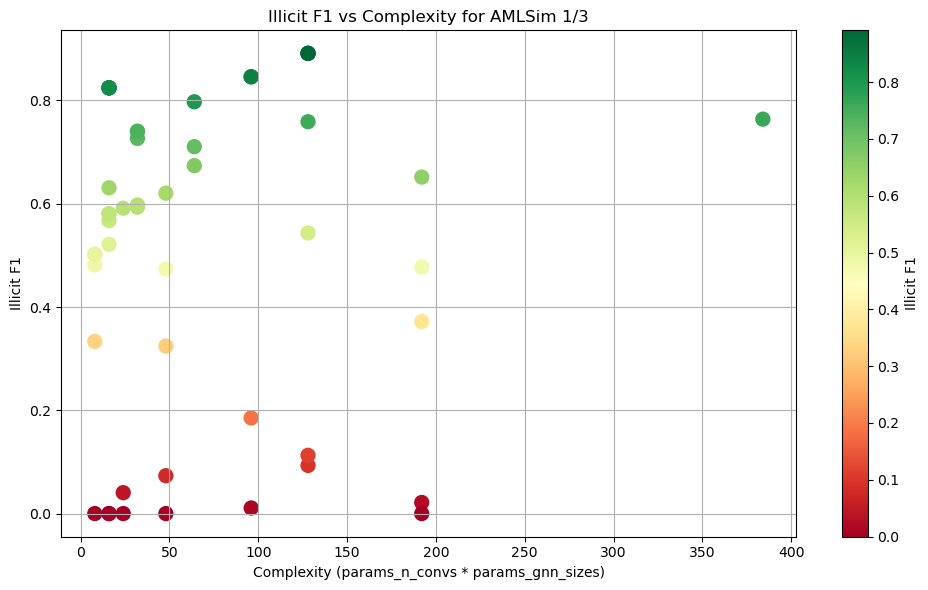

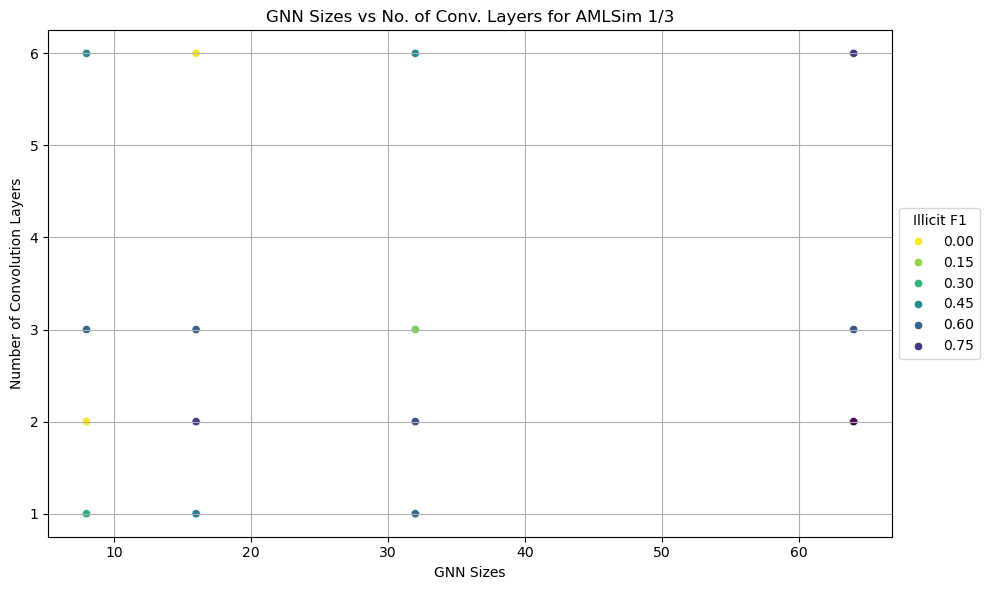

In [24]:
rsu.build_and_save_study_analysis(study_amlsim_31, "AMLSim 1/3")

Best trials

In [25]:
rsu.get_study_trials(study_amlsim_31).head(3)

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_linkpred_sizes,params_n_convs,params_n_linkpred,state
29,29,0.919734,0.891192,128.0,2025-01-10 15:25:47.738814,2025-01-10 15:25:49.053993,0 days 00:00:01.315179,"('add', 'min', 'max')",concat,64,16,2,2,COMPLETE
30,30,0.919734,0.891192,128.0,2025-01-10 15:25:49.054419,2025-01-10 15:25:50.458462,0 days 00:00:01.404043,"('add', 'min', 'max')",concat,64,16,2,2,COMPLETE
40,40,0.919734,0.891192,128.0,2025-01-10 15:26:02.532427,2025-01-10 15:26:03.820603,0 days 00:00:01.288176,"('add', 'min', 'max')",concat,64,16,2,2,COMPLETE


## AMLSim 1/5

### AMLSim 1/5 studies analysis

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_linkpred_sizes,params_n_convs,params_n_linkpred,state
0,0,0.515528,0.122449,128.0,2025-01-10 15:26:16.708623,2025-01-10 15:26:18.285659,0 days 00:00:01.577036,('softmax'),mean,64,16,2,1,COMPLETE
1,1,0.693846,0.469314,16.0,2025-01-10 15:26:18.285922,2025-01-10 15:26:18.950614,0 days 00:00:00.664692,('add'),concat,16,32,1,2,COMPLETE
2,2,0.451426,0.000000,96.0,2025-01-10 15:26:18.950959,2025-01-10 15:26:20.851908,0 days 00:00:01.900949,('add'),concat,16,64,6,3,COMPLETE


#### Feature importances

{'gnn_sizes': 0.06695771137654208,
 'n_convs': 0.06358694156125494,
 'aggr': 0.007911358279769373,
 'n_linkpred': 0.00695585017404852,
 'linkpred_sizes': 0.003239824546235944,
 'embed_reduction_mode': 0.0010015301154521383}

,Source,SS,DF,MS,F,p-unc,np2,Significance
0,Conv. Dim.,0.0000,3.0,0.0000,0.0000,1.0000,0.0000,No
1,No. Conv. Layers,0.0000,3.0,0.0000,0.0000,1.0000,0.0000,No
2,Aggr.,0.0000,2.0,0.0000,0.0000,1.0000,0.0000,No
3,Embed Reduction,-0.0000,1.0,-0.0000,-0.0000,1.0000,-0.0000,No
4,Conv. Dim. * No. Conv. Layers,-0.0000,9.0,-0.0000,-0.0000,1.0000,-0.0000,No
5,Conv. Dim. * Aggr.,0.0000,6.0,0.0000,0.0000,1.0000,0.0000,No
6,No. Conv. Layers * Aggr.,0.0000,6.0,0.0000,0.0000,1.0000,0.0000,No
7,Conv. Dim. * Embed Reduction,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
8,No. Conv. Layers * Embed Reduction,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
9,Aggr. * Embed Reduction,-0.0000,2.0,-0.0000,-0.0000,1.0000,-0.0000,No


#### Plots

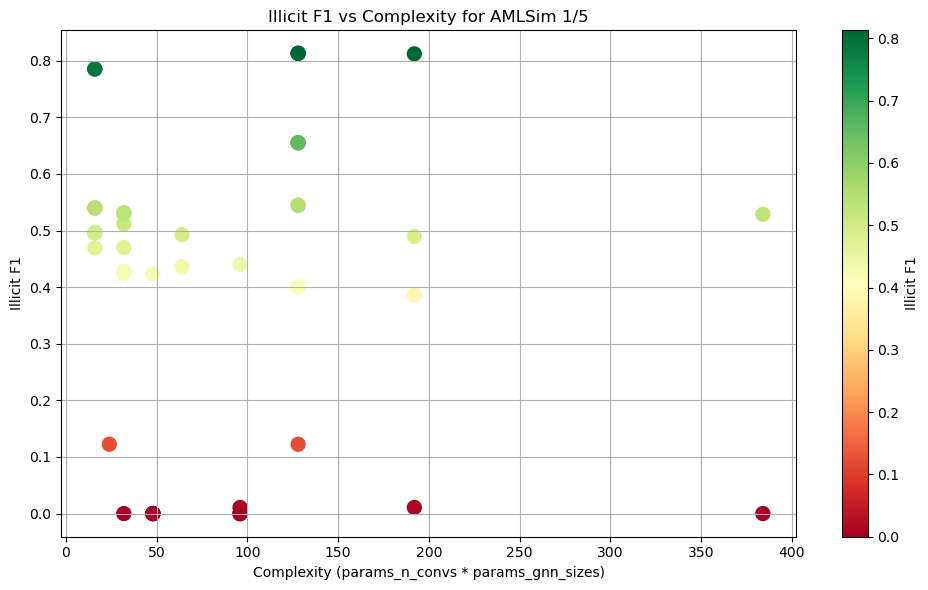

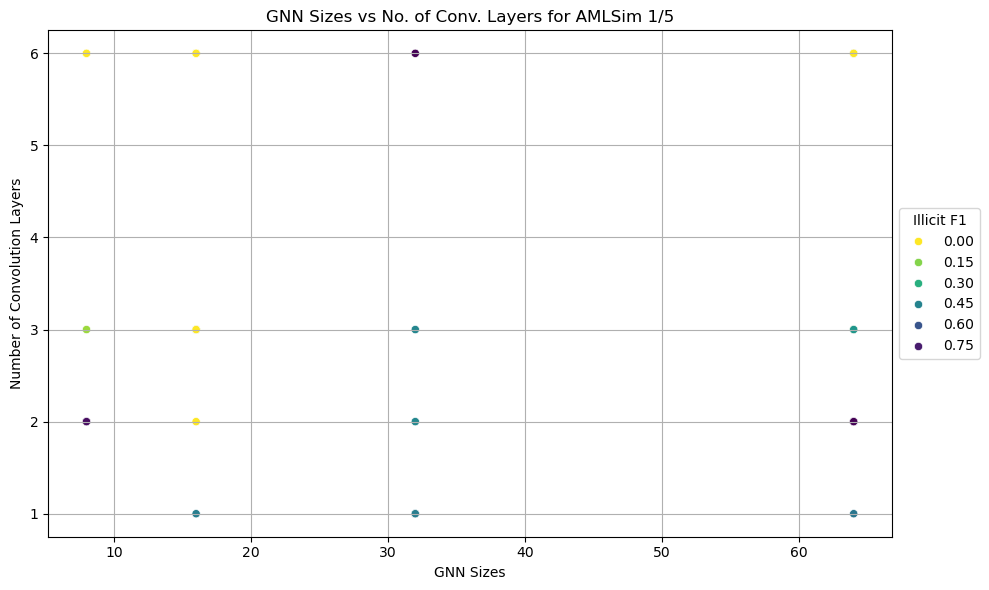

In [26]:
study_amlsim_51 = rsu.load_study("amlsim_51")
rsu.build_and_save_study_analysis(study_amlsim_51, "AMLSim 1/5")

In [27]:
rsu.get_study_trials(study_amlsim_51).head(3)

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_linkpred_sizes,params_n_convs,params_n_linkpred,state
23,23,0.886317,0.813008,128.0,2025-01-10 15:26:51.017555,2025-01-10 15:26:52.605376,0 days 00:00:01.587821,('add'),concat,64,64,2,2,COMPLETE
33,33,0.886317,0.813008,128.0,2025-01-10 15:27:08.981549,2025-01-10 15:27:10.397109,0 days 00:00:01.415560,('add'),concat,64,64,2,2,COMPLETE
41,41,0.886317,0.813008,128.0,2025-01-10 15:27:22.417097,2025-01-10 15:27:23.781278,0 days 00:00:01.364181,('add'),concat,64,64,2,2,COMPLETE


## AMLSim 1/10

### AMLSim 1/10 studies analysis

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_linkpred_sizes,params_n_convs,params_n_linkpred,state
0,0,0.690456,0.413793,128.0,2025-01-10 15:27:36.142051,2025-01-10 15:27:37.824924,0 days 00:00:01.682873,('softmax'),mean,64,16,2,1,COMPLETE
1,1,0.659573,0.355932,16.0,2025-01-10 15:27:37.825162,2025-01-10 15:27:38.825588,0 days 00:00:01.000426,('add'),concat,16,32,1,2,COMPLETE
2,2,0.591106,0.221154,96.0,2025-01-10 15:27:38.825823,2025-01-10 15:27:40.867472,0 days 00:00:02.041649,('add'),concat,16,64,6,3,COMPLETE


#### Feature importances

{'n_linkpred': 0.06684500643334944,
 'n_convs': 0.041145940884029036,
 'gnn_sizes': 0.021314929422035226,
 'linkpred_sizes': 0.009271774154214407,
 'embed_reduction_mode': 0.005897656130692748,
 'aggr': 0.005256460253971245}

,Source,SS,DF,MS,F,p-unc,np2,Significance
0,Conv. Dim.,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
1,No. Conv. Layers,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
2,Aggr.,-0.0000,2.0,-0.0000,-0.0000,1.0000,-0.0000,No
3,Embed Reduction,-0.0000,1.0,-0.0000,-0.0000,1.0000,-0.0000,No
4,Conv. Dim. * No. Conv. Layers,0.0000,9.0,0.0000,0.0000,1.0000,0.0000,No
5,Conv. Dim. * Aggr.,-0.0000,6.0,-0.0000,-0.0000,1.0000,-0.0000,No
6,No. Conv. Layers * Aggr.,-0.0000,6.0,-0.0000,-0.0000,1.0000,-0.0000,No
7,Conv. Dim. * Embed Reduction,0.0000,3.0,0.0000,0.0000,1.0000,0.0000,No
8,No. Conv. Layers * Embed Reduction,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
9,Aggr. * Embed Reduction,0.0000,2.0,0.0000,0.0000,1.0000,0.0000,No


#### Plots

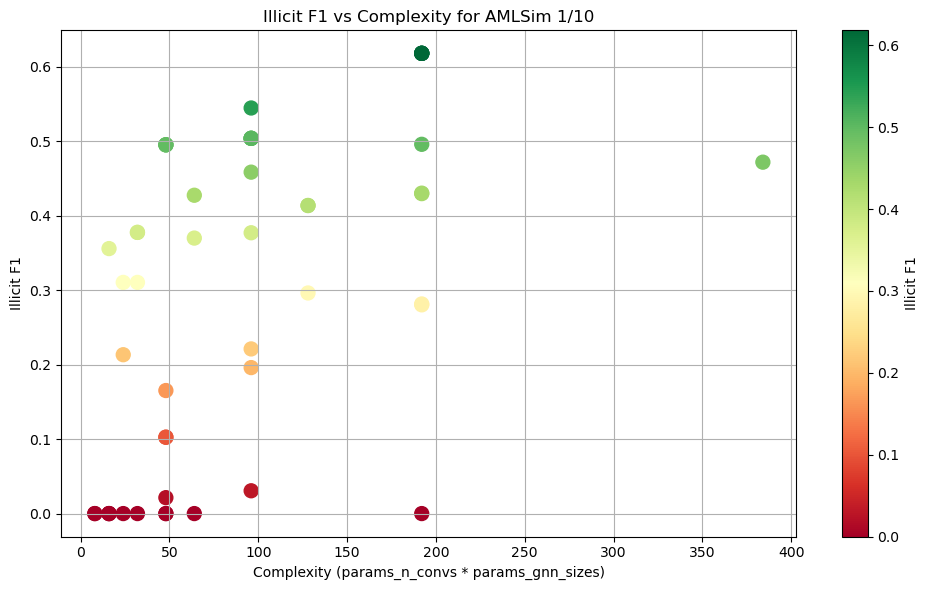

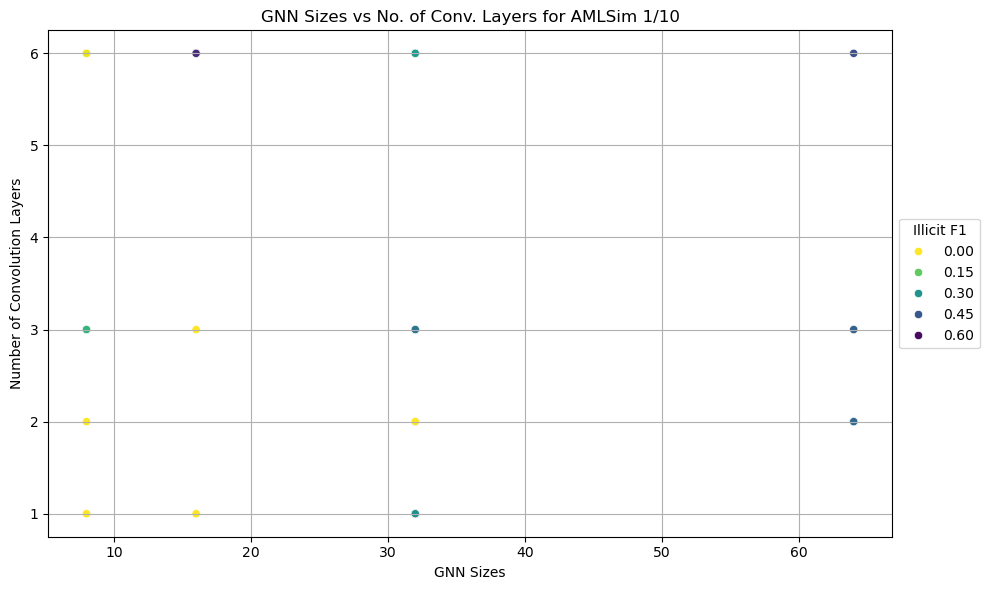

In [28]:
study_amlsim_101 = rsu.load_study("amlsim_101")
rsu.build_and_save_study_analysis(study_amlsim_101, "AMLSim 1/10")

In [29]:
rsu.get_study_trials(study_amlsim_101).head(3)

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_linkpred_sizes,params_n_convs,params_n_linkpred,state
12,12,0.796264,0.618182,192.0,2025-01-10 15:27:52.852497,2025-01-10 15:27:56.576673,0 days 00:00:03.724176,"('add', 'min', 'max')",concat,32,8,6,1,COMPLETE
22,22,0.796264,0.618182,192.0,2025-01-10 15:28:12.000430,2025-01-10 15:28:15.770859,0 days 00:00:03.770429,"('add', 'min', 'max')",concat,32,8,6,1,COMPLETE
23,23,0.796264,0.618182,192.0,2025-01-10 15:28:15.771196,2025-01-10 15:28:19.523984,0 days 00:00:03.752788,"('add', 'min', 'max')",concat,32,8,6,1,COMPLETE


## AMLSim 1/20

In [30]:
study_amlsim_120 = rsu.load_study("amlsim_201")

### AMLSim 1/20 studies analysis

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_linkpred_sizes,params_n_convs,params_n_linkpred,state
0,0,0.672125,0.397059,128.0,2025-01-10 15:29:07.751765,2025-01-10 15:29:10.629582,0 days 00:00:02.877817,('softmax'),mean,64,16,2,1,COMPLETE
1,1,0.671364,0.364912,16.0,2025-01-10 15:29:10.630045,2025-01-10 15:29:11.828856,0 days 00:00:01.198811,('add'),concat,16,32,1,2,COMPLETE
2,2,0.619898,0.326403,96.0,2025-01-10 15:29:11.829402,2025-01-10 15:29:14.722967,0 days 00:00:02.893565,('add'),concat,16,64,6,3,COMPLETE


#### Feature importances

{'n_convs': 0.03133353089756883,
 'gnn_sizes': 0.026822195261845316,
 'linkpred_sizes': 0.008563793780516651,
 'embed_reduction_mode': 0.003914743874494163,
 'n_linkpred': 0.00029739377099449277,
 'aggr': 0.00019859773078716655}

,Source,SS,DF,MS,F,p-unc,np2,Significance
0,Conv. Dim.,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
1,No. Conv. Layers,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
2,Aggr.,0.0000,2.0,0.0000,0.0000,1.0000,0.0000,No
3,Embed Reduction,0.0000,1.0,0.0000,0.0000,1.0000,0.0000,No
4,Conv. Dim. * No. Conv. Layers,0.0000,9.0,0.0000,0.0000,1.0000,0.0000,No
5,Conv. Dim. * Aggr.,0.0000,6.0,0.0000,0.0000,1.0000,0.0000,No
6,No. Conv. Layers * Aggr.,0.0000,6.0,0.0000,0.0000,1.0000,0.0000,No
7,Conv. Dim. * Embed Reduction,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
8,No. Conv. Layers * Embed Reduction,-0.0000,3.0,-0.0000,-0.0000,1.0000,-0.0000,No
9,Aggr. * Embed Reduction,-0.0000,2.0,-0.0000,-0.0000,1.0000,-0.0000,No


#### Plots

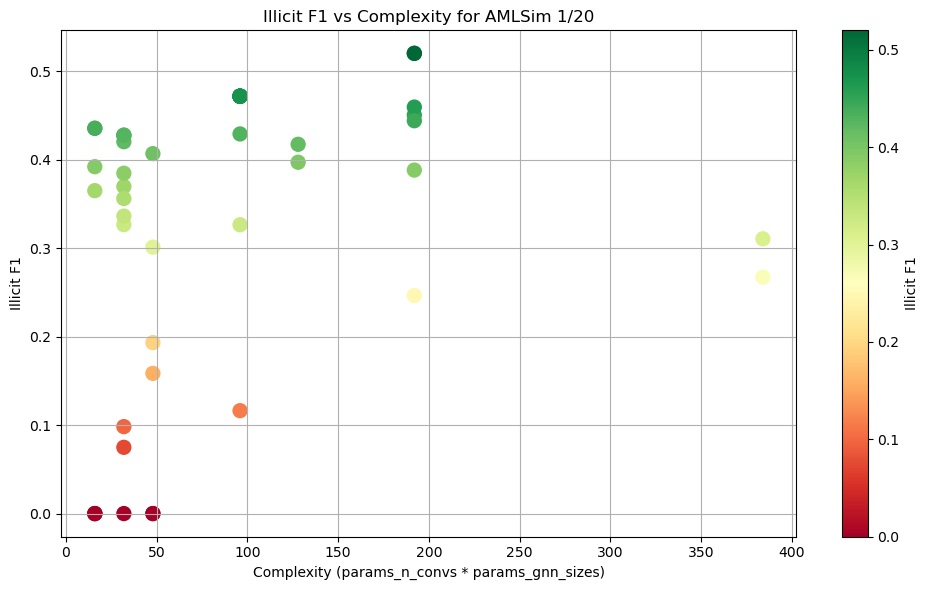

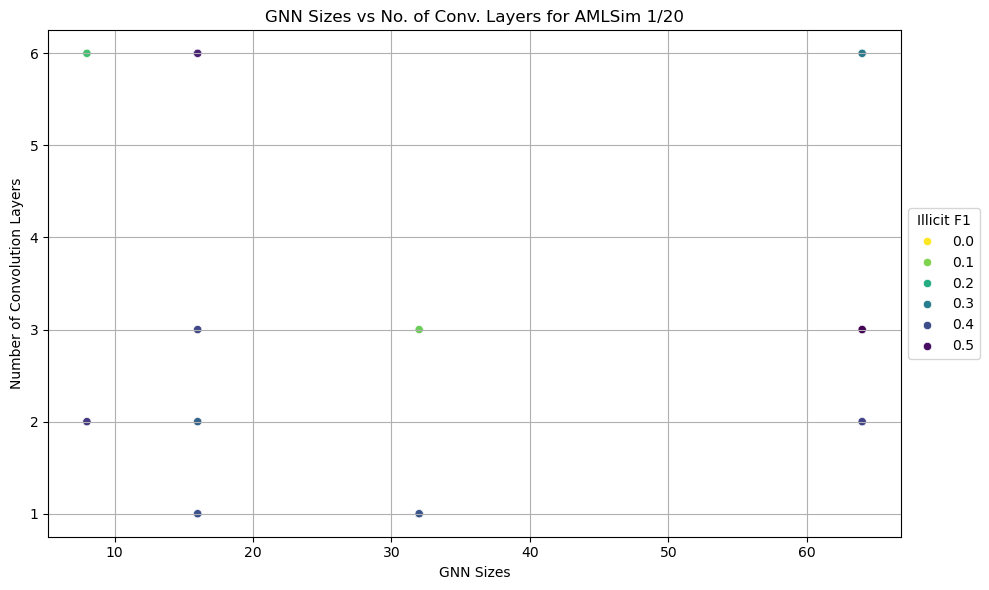

In [31]:
rsu.build_and_save_study_analysis(study_amlsim_120, "AMLSim 1/20")

In [33]:
rsu.get_study_trials(study_amlsim_120, (1, 2), (False, True)).head(3)

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_aggr,params_embed_reduction_mode,params_gnn_sizes,params_linkpred_sizes,params_n_convs,params_n_linkpred,state
28,28,0.748965,0.520107,192.0,2025-01-10 15:30:38.805412,2025-01-10 15:30:44.973570,0 days 00:00:06.168158,"('add', 'min', 'max')",mean,64,16,3,3,COMPLETE
30,30,0.748965,0.520107,192.0,2025-01-10 15:30:49.330519,2025-01-10 15:30:27.772894,-1 days +23:59:38.442375,"('add', 'min', 'max')",mean,64,16,3,3,COMPLETE
33,33,0.724907,0.471642,96.0,2025-01-10 15:30:29.704766,2025-01-10 15:30:31.878285,0 days 00:00:02.173519,('add'),mean,16,32,6,1,COMPLETE
